# Fraud Detection — Unsupervised vs Supervised Approach

This notebook explores a credit-card application fraud dataset through two complementary lenses:

1. **Unsupervised anomaly detection** (Isolation Forest) on unlabeled data  
2. **Supervised classification** (Logistic Regression) once ground-truth labels are available  

The goal is to compare how well each approach identifies fraudulent applications and to understand which features drive the predictions.

---
## 1 · Setup & Imports

KeyError: 'balance'

In [1]:
import warnings

# Uncomment to suppress warnings during development
# warnings.filterwarnings('ignore')

%matplotlib inline

# Core libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

# Data splitting and cross-validation
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, TimeSeriesSplit

# Preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, TargetEncoder
from sklearn.cluster import KMeans

# Models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor, IsolationForest

# Evaluation metrics
from sklearn.metrics import (
    classification_report, make_scorer, fbeta_score, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
    mean_squared_error, r2_score, mean_absolute_error, silhouette_score)

print("libraries imported successfully")

libraries imported successfully


/home/daniel/python/DS_projects/Credit_card_fraud/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 · Exploratory Data Analysis

Before building any model we inspect the raw data, looking for anomalies, sentinel values (`-1` used as a missing indicator), and patterns worth special treatment.

In [9]:
df = pd.read_csv('../data/Base_unlabeled.csv')
how_many_10 = (df['customer_age'] == 10).sum()/len(df)*100
#print(how_many_10)

#answer is 2% so there isn't a lot of 10 year olds in the dataset. We will keep them in the dataset for now.



from itertools import combinations


# 1. Define your target columns
target_cols = [
    "current_address_months_count",
    "credit_risk_score",
    "session_length_in_minutes",
    "device_distinct_emails_8w",
    "prev_address_months_count",
]

# 2. Loop through every unique pair and count the matches
pair_counts = {}
list_pairs = list(combinations(target_cols, 2))
for col1, col2 in combinations(target_cols, 2):
    # Check where both columns equal -1 in the same row
    match_count = ((df[col1] == -1) & (df[col2] == -1)).sum()

    # Store the result with a readable pair name
    pair_counts[f"{col1} & {col2}"] = match_count

# 3. Convert the results into a clean DataFrame for easy viewing
results_df = pd.DataFrame(
    list(pair_counts.items()), columns=["Column Pair", "Row Count"]
)
#print(results_df)


#checking the number of missing values in each target column
total_num = []
missing_values = df[target_cols] == -1
missing_values = missing_values.sum()



# 1. Split the "Column Pair" string into two separate temporary column names
results_df["Col1"] = results_df["Column Pair"].apply(
    lambda x: x.split(" & ")[0].strip()
)
results_df["Col2"] = results_df["Column Pair"].apply(
    lambda x: x.split(" & ")[1].strip()
)
#print(results_df)

# 2. Use your existing 'missing_values' Series to look up the totals
results_df["Col1_Total_-1"] = results_df["Col1"].map(missing_values)
results_df["Col2_Total_-1"] = results_df["Col2"].map(missing_values)

# 3. Calculate the percentages
results_df["% of Col1 rows"] = (
    results_df["Row Count"] / results_df["Col1_Total_-1"]
) * 100
results_df["% of Col2 rows"] = (
    results_df["Row Count"] / results_df["Col2_Total_-1"]
) * 100

# 4. Create the clean final DataFrame
percentage_df = results_df[
    [
        "Column Pair",
        "Row Count",
        "Col1_Total_-1",
        "Col2_Total_-1",
        "% of Col1 rows",
        "% of Col2 rows",
    ]
]
print(percentage_df.round(2))

def calculate_lift(row):
    lift_1_to_2 = (row["% of Col2 rows"]/row["Col1_Total_-1"])*10000  
    lift_2_to_1 = (row["% of Col1 rows"]/row["Col2_Total_-1"])*10000  
    
    return pd.Series({'lift_1_to_2': lift_1_to_2, 'lift_2_to_1': lift_2_to_1})
lift_df = pd.DataFrame()
lift_df[['lift_1_to_2', 'lift_2_to_1']] = calculate_lift(percentage_df)

print(lift_df.round(2))



print(total_num)

print(missing_values)




# We see that for 60% of the missing values of "device_distinct_emails_8w" there is also a missing value in "session_length_in_minutes", maybe indicating a relationship between the two. We will keep this in mind for later analysis.

# We see indeed that "prev_address_months_count" has a lot of missing values, yet no relation between it's missing values and the other target columns. Our assumption is that this column is not very useful for our analysis and we will drop it from the dataset.

df = df.drop("prev_address_months_count", axis=1) #dropping this column because it has too many missing values



                                         Column Pair  Row Count  \
0   current_address_months_count & credit_risk_score          1   
1  current_address_months_count & session_length_...          4   
2  current_address_months_count & device_distinct...          0   
3  current_address_months_count & prev_address_mo...         86   
4      credit_risk_score & session_length_in_minutes          2   
5      credit_risk_score & device_distinct_emails_8w          1   
6      credit_risk_score & prev_address_months_count        387   
7  session_length_in_minutes & device_distinct_em...        231   
8  session_length_in_minutes & prev_address_month...       1518   
9  device_distinct_emails_8w & prev_address_month...        291   

   Col1_Total_-1  Col2_Total_-1  % of Col1 rows  % of Col2 rows  
0           4254            488            0.02            0.20  
1           4254           2015            0.09            0.20  
2           4254            359            0.00            0.00 

/tmp/ipykernel_456229/2899635915.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lift_df[['lift_1_to_2', 'lift_2_to_1']] = calculate_lift(percentage_df)
/tmp/ipykernel_456229/2899635915.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lift_df[['lift_1_to_2', 'lift_2_to_1']] = calculate_lift(percentage_df)


In [7]:
#the raw data we will be working with
df = pd.read_csv('../data/Base_unlabeled.csv')



In [28]:
#have a first look on the dataset, checking for some wierd column names, or wierd values
#df.head()

#Having a look at the dataset's information, summary statistics, target variable distribution, and missing values to get a better understanding of the data
#df.info()

#Having a look at the dataset's summary statistics, target variable distribution, and missing values to get a better understanding of the data
#df.describe(include='all')


mask = df['velocity_24h'] > df['velocity_4w']
print(f"Violations: {mask.sum()} rows ({mask.mean()*100:.2f}%)")
df[mask].head()



Violations: 440147 rows (44.01%)


,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,...,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,balance_to_income_ratio
0,0.3,0.986506,-0.700855,40,0.006735,102.453711,AA,1059,13096.035020,7850.955007,...,9.0,0,1500,0,INTERNET,1.078515,linux,1,-0.107735,341.512370
3,0.6,0.475100,-0.825276,30,0.006991,-1.863101,AB,3483,14431.993620,6755.344479,...,1.0,0,200,0,INTERNET,0.952889,linux,1,-0.107735,-3.105168
5,0.6,0.294840,3.190141,30,0.024232,-1.232556,AD,1204,11556.955510,7506.951276,...,30.0,0,200,0,INTERNET,-0.071573,linux,1,-0.107735,-2.054260
6,0.2,0.773085,-0.938387,40,0.006919,-0.544676,AB,1998,11723.993610,7864.277144,...,1.0,0,200,0,INTERNET,2.569433,x11,1,-0.107735,-2.723382
12,0.1,0.767432,-0.599056,20,0.021346,-0.669856,AB,2491,6652.516398,6720.662514,...,30.0,0,200,0,INTERNET,-0.418633,other,0,5.551570,-6.698555


### Key Observations from Initial Inspection

### Decision: Drop `prev_address_months_count`

`prev_address_months_count` had **71 %** unknown / sentinel values, making it unreliable.  
Additionally, its correlation with `current_address_months_count` was negligible (≈ 0), so dropping it loses very little signal.

In [33]:
import sys
import os

# 1. Tell Python to look one folder up where the 'src' folder lives
sys.path.append(os.path.abspath(os.path.join('..')))

# 2. Force the notebook to auto-update if you ever edit engineering.py
%load_ext autoreload
%autoreload 2

# 3. Import the engine function you created!
from src.engineering import create_fraud_features

# 4. Run it on your DataFrame
df = create_fraud_features(df)


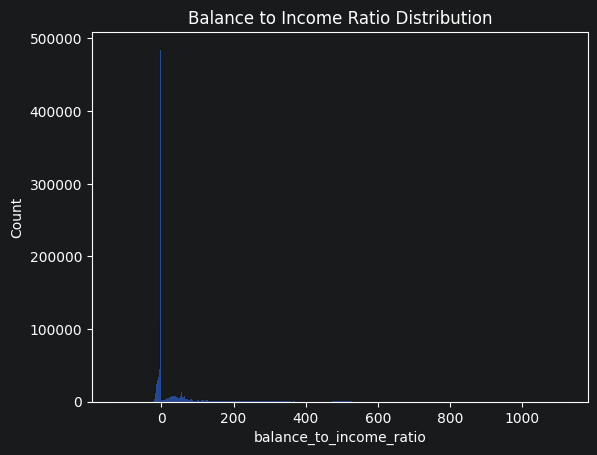

90th percentile: 69.63
Rows above 90th percentile: 100000
Of those, velocity violations: 65967
Percentage: 65.97%


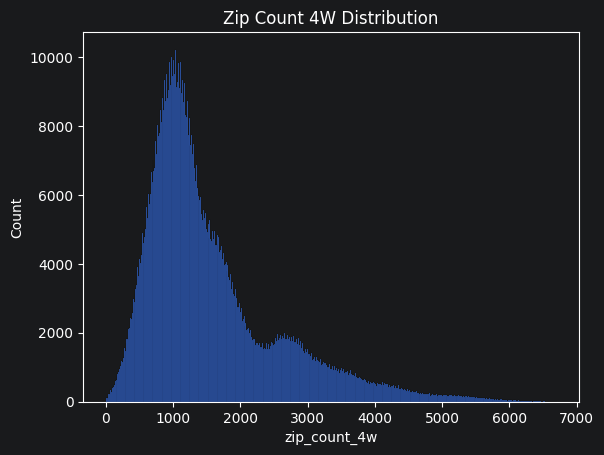

Mean: 1572.69
Variance: 1010778.02
P(high zip 95th): 0.0500
P(high balance ratio 95th): 0.0500
P(both): 0.0034
P(high balance | high zip): 0.0681

Lift: 1.36x
→ Independent signals
                  Feature1                Feature2  Correlation
1  balance_to_income_ratio  intended_balcon_amount     0.669161
0              velocity_4w            velocity_24h     0.539115


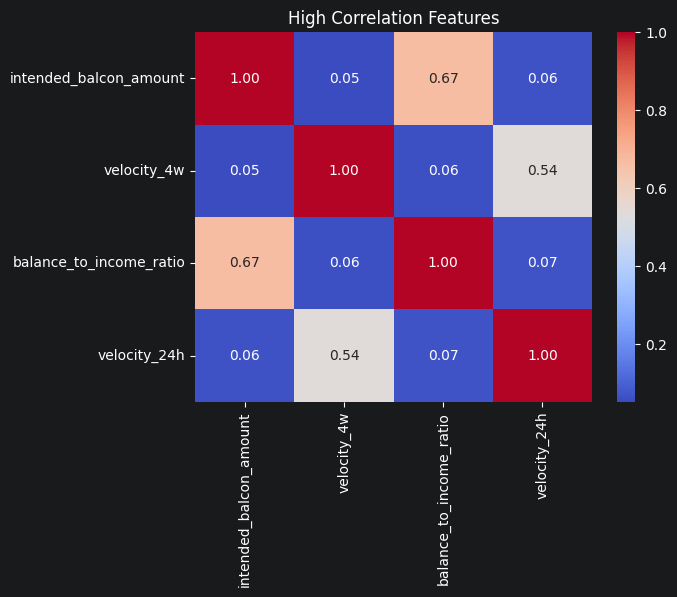

Rows after cleaning: 1000000


In [34]:

sns.histplot(df['balance_to_income_ratio'], bins=500)
plt.title('Balance to Income Ratio Distribution')
plt.show()
threshold = df['balance_to_income_ratio'].quantile(0.90)
print(f"90th percentile: {threshold:.2f}")
# Get the 90th percentile threshold
threshold_90 = df['balance_to_income_ratio'].quantile(0.90)

# Filter rows above 90th percentile
high_ratio = df[df['balance_to_income_ratio'] > threshold_90]

# Check how many of those also have velocity violation
velocity_violation = high_ratio[high_ratio['velocity_6h'] > high_ratio['velocity_24h']]

print(f"Rows above 90th percentile: {len(high_ratio)}")
print(f"Of those, velocity violations: {len(velocity_violation)}")
print(f"Percentage: {len(velocity_violation)/len(high_ratio)*100:.2f}%")
sns.histplot(df['zip_count_4w'], bins=500)
plt.title('Zip Count 4W Distribution')
plt.show()
print(f"Mean: {df['zip_count_4w'].mean():.2f}")
print(f"Variance: {df['zip_count_4w'].var():.2f}")
# Define thresholds at 95th percentile
balance_threshold = df['balance_to_income_ratio'].quantile(0.95)
zip_threshold = df['zip_count_4w'].quantile(0.95)

# Create flags
high_balance = df['balance_to_income_ratio'] > balance_threshold
high_zip = df['zip_count_4w'] > zip_threshold

# Probabilities
p_high_zip = high_zip.mean()
p_high_balance = high_balance.mean()
p_both = (high_balance & high_zip).mean()
p_high_balance_given_high_zip = (high_balance & high_zip).sum() / high_zip.sum()

print(f"P(high zip 95th): {p_high_zip:.4f}")
print(f"P(high balance ratio 95th): {p_high_balance:.4f}")
print(f"P(both): {p_both:.4f}")
print(f"P(high balance | high zip): {p_high_balance_given_high_zip:.4f}")

lift = p_high_balance_given_high_zip / p_high_balance
print(f"\nLift: {lift:.2f}x")
print("→ Strong correlation — likely same fraud pattern" if lift > 1.5 else "→ Independent signals")


#heat map was built with the help of AI
num_cols = ['income', 'name_email_similarity',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'intended_balcon_amount', 'zip_count_4w', 'velocity_6h',
            'velocity_24h', 'velocity_4w', 'bank_months_count',
            'proposed_credit_limit', 'session_length_in_minutes',
            'balance_to_income_ratio']

corr_matrix = df[num_cols].corr().abs()

# Get upper triangle only to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with correlation above 0.5
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > 0.5]

high_corr_df = pd.DataFrame(high_corr, columns=['Feature1', 'Feature2', 'Correlation'])
print(high_corr_df.sort_values('Correlation', ascending=False))

# Only plot columns that actually have high correlation

relevant_cols = list(set(high_corr_df['Feature1'].tolist() + high_corr_df['Feature2'].tolist()))

sns.heatmap(df[relevant_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('High Correlation Features')
plt.show()





# Recreate balance_to_income_ratio after cleaning
df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']

print(f"Rows after cleaning: {len(df)}")

## 3 · Data Cleaning & Feature Engineering

In [18]:
#creating the balance to income ratio feature

df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']

print(df['balance_to_income_ratio'].describe())

count    1000000.000000
mean          24.045123
std           83.728224
min         -129.946508
25%           -2.571247
50%           -1.299149
75%            8.865805
max         1119.684953
Name: balance_to_income_ratio, dtype: float64


In [19]:
#Data cleaning
target_cols = [
    "current_address_months_count",
    "credit_risk_score",
    "session_length_in_minutes",
    "device_distinct_emails_8w",
    ]
#print("Before scaling:")
#print(df[target_cols].head())
df[target_cols] = df[target_cols].replace(-1, np.nan)   # Ensure -1 is treated as NaN for imputation
missing_mask = df[target_cols].isna().any(axis=1)
mask_rows = df[missing_mask].copy()  # Store rows with missing values for later analysis

df[target_cols] = StandardScaler().fit_transform(df[target_cols])

import time
sample = df[target_cols].sample(10000, random_state=1)
start = time.time()
KNNImputer(n_neighbors=5).fit_transform(sample)
print(time.time() - start)
#print(df[target_cols].head())

## Now we can proceed for the KNNImputer for the missing values in the target columns. We will use KNNImputer to fill in the missing values based on the nearest neighbors.

df[target_cols] = KNNImputer(n_neighbors=5).fit_transform(df[target_cols]) #we don't want to miss outliers so we leave the n_neighbors to 5.
print("mask_rows:")
print(df.loc[missing_mask.index[missing_mask]].copy())
print(mask_rows.head())


0.03701639175415039


KeyboardInterrupt: 

In [21]:

#print(df.corr(numeric_only=True))

# Checking the relation between prev_adress_month_count to curr_adress_month_count

rows = (df['prev_address_months_count'] != -1) & (df['current_address_months_count'] != -1)
mask = df.loc[rows, ['prev_address_months_count', 'current_address_months_count']]
print(mask.corr(numeric_only=True))


KeyError: 'prev_address_months_count'

In [22]:

#removing the prev_address_months_count column since it has too many missing values and doesn't seem to have a strong correlation with other features.
df = df.drop("prev_address_months_count", axis=1) #dropping this

KeyError: "['prev_address_months_count'] not found in axis"

### Correlation Insights

Examining the numeric columns revealed several useful relationships:

- **`credit_risk_score`** correlates strongly with `bank_branch_count_8w` — both capture financial-history signals.  
- **Velocity features** (`velocity_6h`, `velocity_24h`, `velocity_4w`) are highly intercorrelated, suggesting short-term transaction bursts are a key fraud indicator.  
- **`name_email_similarity`** shows a moderate positive correlation with `customer_age`, indicating that older applicants tend to have more consistent name-email combinations.

In [ ]:
# dealing the categorical columns



In [23]:
#Basic raw algorithm for the dataset using cluster analysis to get a baseline performance metric for the model
num_cols = ['income', 'name_email_similarity',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'intended_balcon_amount','zip_count_4w','velocity_6h','velocity_24h','velocity_4w','bank_months_count','bank_branch_count_8w',
            'proposed_credit_limit','date_of_birth_distinct_emails_4w', 'session_length_in_minutes',
            'balance_to_income_ratio', 'device_distinct_emails_8w']

cat_cols = ['payment_type', 'source','employment_status', 'device_os','housing_status']

binary_cols = ['phone_home_valid','phone_mobile_valid','email_is_free', 'foreign_request', 'has_other_cards',
            'keep_alive_session']



### Feature Selection Notes

Several columns were set aside because they either contained too many missing values or showed no meaningful variation relevant to fraud detection.  
The remaining features are split into three groups for the preprocessing pipeline: **numeric**, **categorical**, and **binary**.

### 3a · KMeans Clustering Attempt

In [24]:
#First we're going to create a preprocessing pipeline for the KMeans model.
sentinel_cols = ['current_address_months_count', 'bank_months_count', 
                 'session_length_in_minutes', 'device_distinct_emails_8w']  
# whichever columns actually use -1 as "missing"
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

Binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', Binary_transformer, binary_cols)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KMeans(random_state=42, n_clusters=5, n_init=10, max_iter=300))
])

print('pipeline created successfully')



pipeline created successfully


In [ ]:
# creating the elbow algorithm to find the optimal number of clusters for the KMeans model
sample = df.sample(50000,random_state=42)
inertias = []
sample = sample.replace(-1, np.nan)  # Ensure -1 is treated as NaN for imputation

for k in range(2, 30,2):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', KMeans(random_state=42, n_clusters=k, n_init=10))])
    pipeline.fit(sample)
    inertias.append(pipeline.named_steps['model'].inertia_)
plt.plot(range(2, 30,2), inertias, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

### Elbow Method — No Clear Cluster Count

The elbow plot did not reveal a distinct "knee", suggesting the data does not separate neatly into a small number of clusters.  
Most of the variance appears to be continuous rather than cluster-shaped.

In [ ]:
#silhouette score to find the optimal number of clusters for the KMeans model

sil_sample = df.sample(10000, random_state=42)   # smaller — silhouette is O(n²)-ish
X = preprocessor.fit_transform(sil_sample)        # preprocess ONCE, outside the loop

sil_scores = []
k_range = range(2, 30,2)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(k, round(score, 4))

plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Silhouette vs k')
plt.show()

### Silhouette Analysis — Poor Cluster Quality

Silhouette scores remained low across all tested values of *k* (≈ 0.07–0.08), confirming that KMeans is not capturing meaningful structure in this feature space.

### Dimensionality Reduction Experiment

To check whether the curse of dimensionality was hurting KMeans, we reduced the feature set and re-ran clustering.

In [ ]:
#now we remove columns that we think are not useful for the model, and we will create a new pipeline with the remaining columns.
num_cols = ['income',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'zip_count_4w','velocity_6h','bank_months_count','bank_branch_count_8w',
            'proposed_credit_limit','date_of_birth_distinct_emails_4w',
            'balance_to_income_ratio', 'device_distinct_emails_8w']

cat_cols = ['payment_type','device_os','housing_status']

binary_cols = ['phone_home_valid','phone_mobile_valid', 'foreign_request', 'has_other_cards']



In [ ]:

#inserting less information to the pipeline to see if we have dimentionality issues
sentinel_cols = ['current_address_months_count', 'bank_months_count', 
                 'session_length_in_minutes', 'device_distinct_emails_8w']  
# whichever columns actually use -1 as "missing"
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan) # Replace -1 with NaN for preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

Binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', Binary_transformer, binary_cols)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KMeans(random_state=42, n_clusters=5, n_init=10, max_iter=300))
])

print('pipeline created successfully')



In [ ]:
#silhouette score to find the optimal number of clusters for the KMeans model

sil_sample = df.sample(10000, random_state=42)   # smaller — silhouette is O(n²)-ish
X = preprocessor.fit_transform(sil_sample)        # preprocess ONCE, outside the loop

sil_scores = []
k_range = range(2, 30,2)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(k, round(score, 4))

plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Silhouette vs k')
plt.show()

### Conclusion: KMeans Is Not the Right Tool Here

Dimensionality reduction did not improve silhouette scores. KMeans assumes compact, spherical clusters — a poor fit for fraud data, where anomalies are sparse outliers rather than a distinct cluster.  

**Next step →** Switch to **Isolation Forest**, which is designed for anomaly detection and does not require cluster structure.

In [ ]:
#Basic raw algorithm for the dataset using cluster analysis to get a baseline performance metric for the model
num_cols = ['income', 'name_email_similarity',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'intended_balcon_amount','zip_count_4w','velocity_6h','velocity_24h','velocity_4w','bank_months_count','bank_branch_count_8w',
            'proposed_credit_limit','date_of_birth_distinct_emails_4w', 'session_length_in_minutes',
            'balance_to_income_ratio', 'device_distinct_emails_8w']

cat_cols = ['payment_type', 'source','employment_status', 'device_os','housing_status']

binary_cols = ['phone_home_valid','phone_mobile_valid','email_is_free', 'foreign_request', 'has_other_cards',
            'keep_alive_session']




### 3b · Isolation Forest (Unsupervised Anomaly Detection)

In [ ]:
df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']
#Replacing the preprocessing pipeline to Isolation Forest model for anomaly detection
sentinel_cols = ['current_address_months_count', 'bank_months_count', 
                 'session_length_in_minutes', 'device_distinct_emails_8w']  
# whichever columns actually use -1 as "missing"
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)  # Replace -1 with NaN for preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

Binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', Binary_transformer, binary_cols)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', IsolationForest(random_state=42, contamination='auto', n_estimators=100, n_jobs=-1))
])

print('pipeline created successfully')



In [ ]:
sample = df.sample(10000, random_state=42)
full_pipeline.fit(sample)
print('fit OK')
full_pipeline.fit(df)



In [ ]:
#checking for NaNs in the transformed data to ensure that the preprocessing pipeline is working correctly and that there are no missing values after transformation.
transformed = full_pipeline.named_steps['preprocessor'].transform(df)
print("NaNs in transformed data:", np.isnan(transformed).sum())  # should be 0


In [ ]:
scores = full_pipeline.named_steps['model'].score_samples(
    full_pipeline.named_steps['preprocessor'].transform(df)
)
chk = df.iloc[scores.argsort()[:1000]]  # Show the 1000 most anomalous rows


In [ ]:
chk.to_csv('anomalous_rows.csv', index=False)  # Save to CSV for further analysis
import os
print(os.getcwd())


In [ ]:
#adding the negative anomaly score to the dataframe for further analysis
df['anomaly_score'] = scores

In [ ]:
chk_describe = chk.describe()
chk.describe()   
#chk_describe.to_csv('anomalous_rows_describe.csv', index=False)  # Save to CSV for further analysis


In [ ]:
df_describe = df.describe()   
df_describe.to_csv('full_dataset_describe.csv', index=False)  # Save to CSV for further analysis

## 4 · Supervised Model — Logistic Regression

With ground-truth labels (`fraud_bool`) now available, we build a supervised Logistic Regression to compare against the unsupervised baseline.  
The pipeline reuses the same preprocessing steps; the model is tuned via GridSearchCV with **average precision** as the scoring metric.

In [3]:
df = pd.read_csv('../data/Base.csv')
df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']
df['balance_to_income_ratio'] = df['balance_to_income_ratio'].replace([np.inf, -np.inf], np.nan)
#pipeline for the logistic regression model
sentinel_cols = ['current_address_months_count', 'bank_months_count', 
                 'session_length_in_minutes', 'device_distinct_emails_8w']  
# whichever columns actually use -1 as "missing"
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)  # Replace -1 with NaN for preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

Binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', Binary_transformer, binary_cols)
])



print('pipeline created successfully')




NameError: name 'num_cols' is not defined

In [43]:
from sklearn.model_selection import train_test_split


X = df[binary_cols + num_cols + cat_cols]  # Load your dataset
y = df['fraud_bool']  # Load your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)  # Stratified split to maintain class distribution

Xt = preprocessor.fit_transform(X_train)
col_max = np.abs(Xt).max(axis=0)
worst = np.argsort(col_max)[-5:]
print("worst column indices:", worst)
print("their max abs values:", col_max[worst])
feature_names = preprocessor.get_feature_names_out()
for i in [13, 16, 14, 15, 4]:
    print(i, feature_names[i])

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter = 1000, class_weight='balanced', n_jobs=-1))
])

param_grid = {
    'model__C': [0.00001,0.0001,0.001, 0.01, 0.1, 1],  # Regularization strength
    'model__penalty': ['l2'],  # Using L2 for Ridge because the data was to complex to use a different solver
    'model__solver': ['liblinear']  # Basic solver that supports L2 penalty and is efficient for large datasets after other solvers failed to converge
}

cross = GridSearchCV(log_reg_pipeline, param_grid, cv=5, scoring='average_precision', n_jobs=2)
# Fit preprocessor on train only
cross.fit(X_train, y_train)

#evaluating the best model

best_model = cross.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]



In [ ]:
print("Best params:", cross.best_params_)
print("Best CV score (average precision):", round(cross.best_score_, 4))
from sklearn.metrics import average_precision_score
ap_logreg_test = average_precision_score(y_test, y_proba)
print(f"LogReg test AP: {ap_logreg_test:.4f}")

Supervised Model — XGBoost


In [6]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

print("Loading data...")
df = pd.read_csv('../data/Base.csv')

# Feature engineering
df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']
df['balance_to_income_ratio'] = df['balance_to_income_ratio'].replace([np.inf, -np.inf], np.nan)

# Sentinel values
sentinel_cols = ['current_address_months_count', 'bank_months_count',
                 'session_length_in_minutes', 'device_distinct_emails_8w']
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)

# Column definitions
num_cols = ['income', 'name_email_similarity',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
            'velocity_4w', 'bank_months_count', 'bank_branch_count_8w',
            'proposed_credit_limit', 'date_of_birth_distinct_emails_4w',
            'session_length_in_minutes', 'balance_to_income_ratio',
            'device_distinct_emails_8w']

cat_cols = ['payment_type', 'source', 'employment_status', 'device_os', 'housing_status']
binary_cols = ['phone_home_valid', 'phone_mobile_valid', 'email_is_free',
               'foreign_request', 'has_other_cards', 'keep_alive_session']

# Preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', binary_transformer, binary_cols)
])

# Train/test split
X = df[binary_cols + num_cols + cat_cols]
y = df['fraud_bool']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost pipeline
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='aucpr'
    ))
])

print("Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)

# Evaluate
y_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
ap = average_precision_score(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
print(f"XGBoost — AP: {ap:.4f} | ROC-AUC: {auc:.4f}")

# Save model + column info
joblib.dump({
    'pipeline': xgb_pipeline,
    'binary_cols': binary_cols,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'sentinel_cols': sentinel_cols
}, '../data/fraud_model.joblib')

print("Model saved to fraud_model.joblib")


Loading data...
scale_pos_weight: 89.7
Training XGBoost...
XGBoost — AP: 0.1599 | ROC-AUC: 0.8839
Model saved to fraud_model.joblib


### Head-to-Head: Isolation Forest vs Logistic Regression

To make the comparison fair, we re-fit an Isolation Forest on the same training split (unsupervised — no labels) and evaluate both models on the identical held-out test set.

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', IsolationForest(random_state=42, n_jobs=-1))
])
full_pipeline.fit(X_train)   # features only — no y, no labels

# Score the SAME test rows LogReg was evaluated on
iso_scores = -full_pipeline.named_steps['model'].score_samples(
    full_pipeline.named_steps['preprocessor'].transform(X_test)
)
ap_iso = average_precision_score(y_test, iso_scores)
print(f"IsolationForest test AP: {ap_iso:.4f}")
print(len(iso_scores), np.std(iso_scores))

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# scores for the same test set, both "higher = more suspicious"
auc_logreg = roc_auc_score(y_test, y_proba)
auc_iso    = roc_auc_score(y_test, iso_scores)

for name, scores, auc in [('LogReg (supervised)', y_proba, auc_logreg),
                          ('IsolationForest (unsupervised)', iso_scores, auc_iso)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=f'{name}, AUC={auc:.3f}')

plt.plot([0, 1], [0, 1], ls='--', color='gray', label='random (AUC=0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Supervised vs Unsupervised')
plt.legend(); plt.show()

print(f"LogReg ROC-AUC:          {auc_logreg:.3f}")
print(f"IsolationForest ROC-AUC: {auc_iso:.3f}")

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

ap_logreg = average_precision_score(y_test, y_proba)
ap_iso    = average_precision_score(y_test, iso_scores)
baseline  = y_test.mean()

for name, scores, ap in [('LogReg (supervised)', y_proba, ap_logreg),
                          ('IsolationForest (unsupervised)', iso_scores, ap_iso)]:
    p, r, _ = precision_recall_curve(y_test, scores)
    plt.plot(r, p, label=f'{name}, AP={ap:.3f}')

plt.axhline(baseline, ls='--', color='gray', label=f'baseline={baseline:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall: Supervised vs Unsupervised')
plt.legend(); plt.show()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Use the SAME preprocessed features the model saw
X_proc = full_pipeline.named_steps['preprocessor'].transform(X_test)

# 2. PCA down to 2 components
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_proc)

# 3. Anomaly flag: top ~1% most anomalous by your iso_scores
threshold = np.quantile(iso_scores, 0.99)   # top 1% most suspicious
is_anomaly = iso_scores >= threshold

# 4. Plot: normal in light, anomalies on top in red
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[~is_anomaly, 0], X_2d[~is_anomaly, 1], s=4, alpha=0.2, label='normal', color='lightsteelblue')
plt.scatter(X_2d[is_anomaly, 0],  X_2d[is_anomaly, 1],  s=8, alpha=0.6, label='flagged anomaly', color='crimson')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('PCA projection: flagged anomalies vs. normal')
plt.legend(); plt.show()

print("Variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))

### PCA Visualisation — Isolation Forest Predictions

Using PCA to project the preprocessed features to 2-D, we plot which test-set points the Isolation Forest flags as anomalies.  
At first glance the anomalies cluster in one corner of the projection, but the overall variance explained is low (≈ 18 %), so this view only captures part of the picture.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Same preprocessed features + same PCA projection as before
X_proc = best_model.named_steps['preprocessor'].transform(X_test)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_proc)

# Logistic regression's fraud predictions (needs a threshold)
y_pred = (y_proba >= 0.5).astype(int)   # 1 = predicted fraud, 0 = predicted normal

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[y_pred == 0, 0], X_2d[y_pred == 0, 1], s=4, alpha=0.2, label='predicted normal', color='lightsteelblue')
plt.scatter(X_2d[y_pred == 1, 0], X_2d[y_pred == 1, 1], s=8, alpha=0.6, label='predicted fraud', color='crimson')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('PCA projection: LogReg predictions')
plt.legend(); plt.show()

### Feature Importance & Sanity Check

We inspect the Logistic Regression coefficients to verify that the model is using sensible signals and to surface any unexpected relationships between features and the fraud label.

In [ ]:
y_pred = (y_proba >= 0.5).astype(int)
print("flagged as fraud:", y_pred.mean())        # fraction flagged
print("actual fraud rate:", y_test.mean())       # ~0.011

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = (y_proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Recall (fraud caught): {tp/(tp+fn):.1%}")
print(f"Precision (of flagged, real fraud): {tp/(tp+fp):.1%}")
print(f"Fraud missed (false negatives): {fn}")

In [ ]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print(coef_df)

sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10))
plt.title('Top 10 Most Important Features')
plt.show()

In [37]:
# The '!' tells Jupyter to run this as a terminal command
# '../' moves out of notebooks/ so pytest can find your tests folder
!python -m pytest ../tests


============================= test session starts ==============================
platform linux -- Python 3.10.12, pytest-9.1.1, pluggy-1.6.0
rootdir: /home/daniel/python/DS_projects/Credit_card_fraud
collected 2 items                                                              

../tests/test_engineering.py ..                                          [100%]

============================== 2 passed in 0.17s ===============================


## 5 · Next Steps

- Build a stronger supervised model (e.g. LightGBM) and compare performance  
- Tune the decision threshold to balance precision and recall for a realistic alerting budget  
- Run SHAP analysis for richer, non-linear feature-importance explanations